# Insertion-Sort and Counting-Sort Comparison

## Introduction
In this notebook two different algorithms are going to be shown, tested and compared: **insertion-sort** and **counting-sort**.
Their performance and how they handle different types of random arrays will be the subject of evaluation.
The algorithmns will be sorting arrays of integers, since counting sort works only on natural numbers.

## Insertion-Sort
### Brief Overview

Insertion-sort works by splicing the array in two parts: one part that is always internally sorted and another which is comprised of yet to be sorted elements.
At each step the algorithmn takes a new element from the second part and **inserts** it in its correct placement in the sorted first part.

### Code

In [1]:
def insertion_sort(array):
    for j in range(len(array)):
        key = array[j]
        i = j - 1
        while i >= 0 and array[i] > key:
            array[i + 1] = array[i]
            i = i - 1
        array[i + 1] = key
    return array

### Example

In [2]:
test_input = [13, 24, 1, 5, 89, 20]
print(insertion_sort(test_input))

[1, 5, 13, 20, 24, 89]


### Performance
It works by sorting **in place**, so it doesn't require additional memory, and it has got a decent performance with few elements.
But time-wise it's quite inefficient as we add more elements: it has a time complexity of **O(n^2)**!

## Counting-Sort
### Brief Overview

Counting-sort is a sorting algorithmn that works in a peculiar way: it doesn't rely on direct comparisons between elements of the array.
Instead the idea behind it is: 
- first, it *counts* how many time each element appears;
- then, for each element i, it counts how many numbers are equal to i or are lesser than it;
- lastly, it uses this information to construct the sorted array.

### Code

In [3]:
def counting_sort(input, k):
    support = [0] * (k + 1)
    output = [0] * len(input)
    
    for i in input:
        support[i] += 1
    for j in range(1, len(support)):
        support[j] += support[j -1]

    for i in reversed(input):
        output[support[i] - 1] = i
        support[i] -= 1
    return output

### Example

In [4]:
test_input = [8, 2, 3, 4, 0, 0, 5, 6, 8, 2, 7, 2, 4, 6, 10]
print(counting_sort(test_input, 10))

[0, 0, 2, 2, 2, 3, 4, 4, 5, 6, 6, 7, 8, 8, 10]


### Performance

#### Conditions

Counting-sort has some conditions that need to be met for it to work: 
1) Each element needs to be a non negative integer;
2) The upper bound (we'll call it k) must be known.

The upper bound can be known beforehand, but sometimes it's necessary to calculate it from scratch. Computing it adds an additional loop through all the items in the array to sort.

Insertion-sort doesn't require any of these conditions. For example, it works on floating point numbers without problems.

#### Memory Performance

Counting-sort **doesn't sort in place**, so it requires a support **array of length k**, making its space complexity **O(k)**. This can be especially costly if the upper bound is quite high, but the number of actually different elements in the array is low.

For example if we had an input array \[2, 1, 300, 0] we'd have a support array of length 300 even if only 4 elements were needed.

#### Time Performance

Despite these limitations Counting-sort has an incredible time complexity of **O(n+k)**! This is possible because it's not a comparison based sort, meaning it by bypasses the lower bound of **n*logn** that those type of sorting algorithms have.

However, because its time complexity depends both on n, the number of elements, and k, the upper bound value of the possible elements, we can have a scenario where k is equal to n squared, or even more! So a high upper bound can cause problems not only with memory, but with time too.

## Testing Experiments

### Completely Random Array, Small Upper Bound

testing completely random array, small upper bound
starting insertion-sort
starting counting-sort


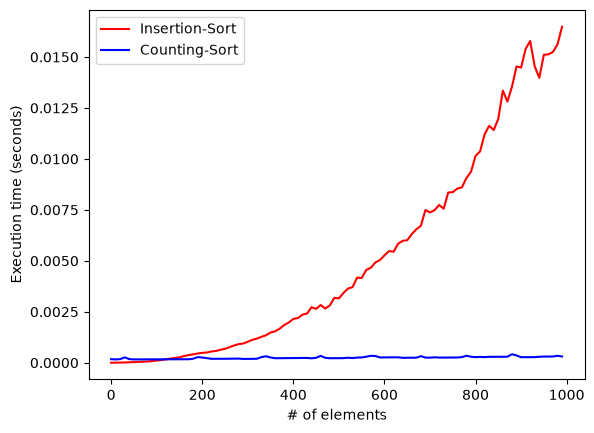

In [5]:
from math import inf
from timeit import default_timer as timer
import matplotlib.pyplot as plt
import random

def test_insertion_sort(inputs, repeats, outputs, step):
    for i in range(0, len(inputs), step):
        best = inf
        for _ in range(repeats):
            start = timer()
            insertion_sort(inputs[:i])
            end = timer()
            best = min(best, end - start)
        time.append(best)

def test_counting_sort(inputs, k, repeats, outputs, step):
    for i in range(0, len(inputs), step):
        best = inf
        for _ in range(repeats):
            start = timer()
            counting_sort(inputs[:i], k)
            end = timer()
            best = min(best, end - start)
        time.append(best)
    

max_number_of_elements = 1000
step = 10
# the x coordinate of the graph
number_of_operation = range(0, max_number_of_elements, step)
# upper bound for the values in the list to sort
interval_end = 3000
# how many times each step of the test is run
number_of_repeats = 5
inputs = random.choices(range(interval_end), k=max_number_of_elements)

print("testing completely random array, small upper bound")

print("starting insertion-sort")
time = []
test_insertion_sort(inputs, number_of_repeats, time, step)
plt.plot(number_of_operation, time, "r", label="Insertion-Sort")

print("starting counting-sort")
time = []
test_counting_sort(inputs, interval_end, number_of_repeats, time, step)
plt.plot(number_of_operation, time, "b", label="Counting-Sort")

plt.xlabel("# of elements")
plt.ylabel("Execution time (seconds)")
plt.legend()
plt.show()

In this case it's clear that counting-sort is by far the more efficient algorithmn of the two, especially when the number of elements gets sufficiently high (around more than 150). Furthermore the time for the counting sort remains quite consistent— this makes sense considering that the upper bound is quite higher than the number of items to sort.

### Completely Random Array, Medium Upper Bound

testing completely random array, medium upper bound
starting insertion-sort
starting counting-sort


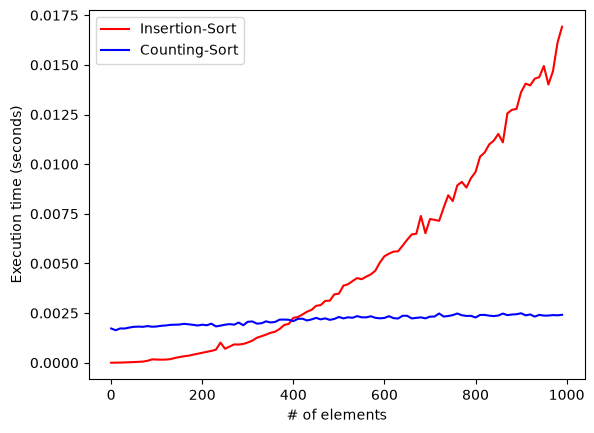

In [6]:
print("testing completely random array, medium upper bound")

interval_end = 30000
inputs = random.choices(range(interval_end), k=max_number_of_elements)

print("starting insertion-sort")
time = []
test_insertion_sort(inputs, number_of_repeats, time, step)
plt.plot(number_of_operation, time, "r", label="Insertion-Sort")

print("starting counting-sort")
time = []
test_counting_sort(inputs, interval_end, number_of_repeats, time, step)
plt.plot(number_of_operation, time, "b", label="Counting-Sort")

plt.xlabel("# of elements")
plt.ylabel("Execution time (seconds)")
plt.legend()
plt.show()

As we can see by increasing the upper bound the point where the two graphs meet has also increased. In this case it increased from ~150 to ~400. 

### Completely Random Array, High Upper Bound

testing with big interval of values
starting insertion-sort
starting counting-sort


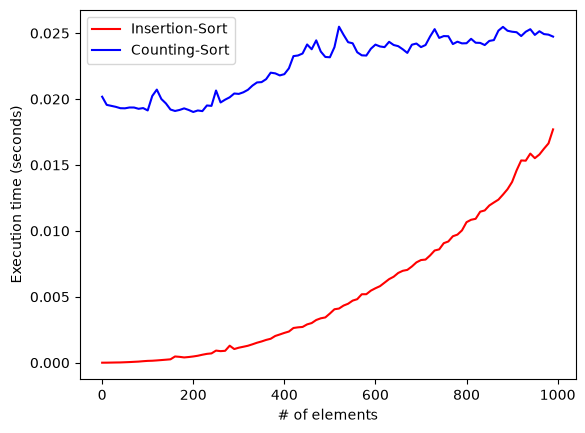

In [7]:
print("testing with big interval of values")

interval_end = 300000
inputs = random.choices(range(interval_end), k=max_number_of_elements)

print("starting insertion-sort")
time = []
test_insertion_sort(inputs, number_of_repeats, time, step)
plt.plot(number_of_operation, time, "r", label="Insertion-Sort")

print("starting counting-sort")
time = []
test_counting_sort(inputs, interval_end, number_of_repeats, time, step)
plt.plot(number_of_operation, time, "b", label="Counting-Sort")
plt.xlabel("# of elements")
plt.ylabel("Execution time (seconds)")
plt.legend()
plt.show()

This is clearly the worst case for counting-sort, given that k is two orders of magnitude higher than the number of elements.

### Already sorted array

testing on already sorted array
starting insertion-sort
starting counting-sort


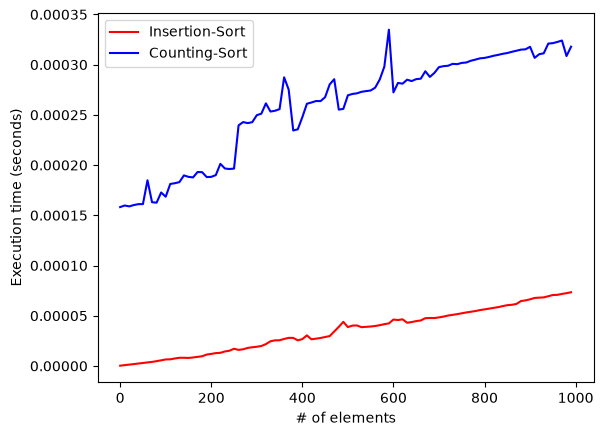

In [8]:
print("testing on already sorted array")

max_number_of_elements = 1000
interval_end = 3000
step = 10
number_of_operation = range(0, max_number_of_elements, step)
inputs = random.choices(range(interval_end), k=max_number_of_elements)
inputs.sort()

print("starting insertion-sort")
time = []
test_insertion_sort(inputs, number_of_repeats, time, step)
plt.plot(number_of_operation, time, "r", label="Insertion-Sort")

print("starting counting-sort")
time = []
test_counting_sort(inputs, interval_end, number_of_repeats, time, step)
plt.plot(number_of_operation, time, "b", label="Counting-Sort")

plt.xlabel("# of elements")
plt.ylabel("Execution time (seconds)")
plt.legend()
plt.show()

Best case for insertion-sort. The cost of insertion sort in this case is O(n) since it only requires insertions-sort to look through each item of the list once to confirm they're in the correct position.

## Conclusions

It's clear that in most cases counting-sort performs better than insertion sort, although it's important to keep in mind that the former does impose some notable constraints. With counting-sort it's impossible to sort non positive integers, its performance depends on the upper bound just as much as it does on the number of elements to sort, and, lastly, it can require a signifiant amount of memory (based more on the upper bound than the number of elements) because it doesn't sort in place.

So insertion-sort, despite having a time complexity of O(n^2), has some use cases. Firstly it still performs well with a few number of elements, secondly it can sort more than just positive integers, thirdly it's quite simple to implement and lastly it doesn't require any additional memory since it sorts in place.

Counting-sort works best when the upper bound is significantly lower than the numbers of elements to sort, making its time complexity pretty much **O(n)**. One common use case for it is to be used as part of **radix sort**, where the upper bound is either 9 (for base 10), or 15 (for hexadecimal).